In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
data = pd.read_csv('C:\\Users\\Admin\\Desktop\\nlp research\\proj data\\sar_data 2.csv')
data.shape

(299414, 5)

In [3]:
tf_idf = TfidfVectorizer(stop_words = 'english', ngram_range = (1, 2), max_features = 299500)
x_tr, x_ts, y_tr, y_ts = train_test_split(data['tweets'], data['sar'])
mnb = MultinomialNB(alpha = 1, fit_prior = True, class_prior = None)
pipe = Pipeline([('tf_idf', tf_idf), ('clf', mnb)])
pipe.fit(x_tr, y_tr)

Pipeline(steps=[('tf_idf',
                 TfidfVectorizer(max_features=299500, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf', MultinomialNB(alpha=1))])

In [4]:
y_pred = pipe.predict(x_ts)

In [5]:
acc = accuracy_score(y_ts, y_pred)
clas = classification_report(y_ts, y_pred)
cm = confusion_matrix(y_ts, y_pred)

print('accuracy: using naive_bayes \n', round(acc,3)*100, '%')
print("report: \n",clas)
print("confusion_matrix: \n", cm)

accuracy: using naive_bayes 
 89.8 %
report: 
               precision    recall  f1-score   support

           0       0.86      0.98      0.92     42985
           1       0.97      0.78      0.87     31869

    accuracy                           0.90     74854
   macro avg       0.92      0.88      0.89     74854
weighted avg       0.91      0.90      0.90     74854

confusion_matrix: 
 [[42259   726]
 [ 6926 24943]]


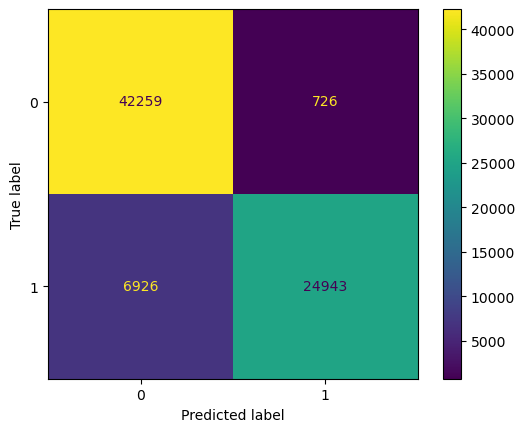

In [6]:
cm_disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm_disp.plot()
plt.savefig('cm_mnb.jpg')
plt.show()

In [8]:
import pickle
pkl_file = "nb_sar.pkl"  

with open(pkl_file, 'wb') as file:  
    pickle.dump(pipe, file)

In [ ]:
with open(pkl_file, 'rb') as file:  
    model = pickle.load(file) 
def test(l_ts):
    y_pre = model.predict(l_ts)
    return y_pre

l_ts = []
sent = input("enter the comment: ")
l_ts.append(sent)
val = test(l_ts)
for pred in val:
    if pred:
        print("sarcastic")
    else:
        print("non-sarcastic")